In [2]:
import pandas as pd

In [3]:
averagedf = pd.read_feather("combined_files_with_metadata.feather")

In [101]:
averagedf.head()

,id,thread_id,author,body,timestamp,unix_timestamp,collected_from_url,author_full,author_followers,author_likes,...,effects,video_path,text_embedding,audio_embedding,video_embedding,fused_embedding,cluster,cluster_prob,umap_x,umap_y
0,7503278148864249110,7503278148864249110,b8d1f8f255488cb47c4febe04f971a80aab7a4aca22e9d1d,Plötzlich ein Digital Detox eingeschoben. 🇮🇹🍝🍋...,2025-05-11 19:51:24,1746985884,https://www.tiktok.com/tag/digitaldetox,1d7f5d2a1d4b4ba9977bee669ad54ba6f50a8c294cb1aa58,5278a6258b81a1e78505052a92e1c3a4c8e4fc4ad59a5ae6,21cd5ce14aa8b1247617265820601ec1b46d1c49813a4798,...,flawless look,videos/7503278148864249110.mp4,"[-3.794837, 0.63037974, 1.509788, 0.1374473, 1...","[0.3237541, -0.11235112, -0.119736336, -0.2200...","[-0.030400887, 0.020024313, -0.00441134, -0.02...","[-0.024680756, 0.010101808, 0.0012954228, -0.0...",-1,0.000000,4.632422,3.140967
1,7558613478487887159,7558613478487887159,ca95e0c8b316e9c32f67a6be190cf4d817573e951fc73bd9,Taking back my last few months of 2025 and sta...,2025-10-07 22:41:11,1759869671,https://www.tiktok.com/tag/digitaldetox,099037d7ed9646b8fc79eb4b084907a4b59cefc8d86723c8,afdbd7df74b4a8d502f03c2c089cbabce8243b8ed4fa2f4f,6b4e6b6fb41591128c5ba448e59bed751ba125521bb084aa,...,flawless look,extracted_from_zips/7558613478487887159.mp4,"[2.0479257, 1.5895466, 2.754304, -5.274406, 0....","[0.0154381795, -0.30264804, -0.035481215, 0.29...","[0.019787952, 0.034039684, 0.0026121866, -0.06...","[0.022484021, 0.019446295, 0.01438221, -0.0536...",5,1.000000,0.358761,3.505548
2,7623749782456028438,7623749782456028438,bdfc15ace6ee5189356097d4cadf2f673d77d6f4b0db3b4d,Imagine checking your notifications in the mid...,2026-04-01 11:22:27,1775035347,https://www.tiktok.com/tag/digitaldetox,43a73602b46bd3cbc78dbf92392cf50e0c9c15c859cb5470,810de21faf6f7d1b4d025deeee888fe1d05f317d353e7b43,22f503370d3761dee860be67d3fd4a14fb9469bc0efab4b2,...,flawless look,extracted_from_zips/7623749782456028438.mp4,"[-1.4934034, 3.337984, -1.4402719, -1.0264286,...","[-0.19018753, -0.383762, -0.36902225, 0.505358...","[0.0012865608, -0.0015610565, 0.009077488, -0....","[-0.012402791, 0.0036785572, -0.01298568, 0.00...",3,0.940509,5.593432,2.040792
3,7623763685936319757,7623763685936319757,8fcdda5bf8e75b159bf36636edb5a67a97de8d494a4318db,Hello! I’m officially back This is what happe...,2026-04-01 12:17:03,1775038623,https://www.tiktok.com/tag/digitaldetox,6371807e713508b0e4f1f72020be685c5f67d8039eeaef2e,ac4ebe42d7d13bedd1eaf2c63e5a19c1aa79dde018123f09,f59dd10cd9248853689fb9e9410d7ef9f334137420e9d973,...,flawless look,extracted_from_zips/7623763685936319757.mp4,"[-0.79755646, -2.2601898, 1.5637699, -4.866456...","[0.2267509, 0.21168669, -0.09216305, 0.1963428...","[0.027527297, 0.0245002, 0.008045874, -0.03352...","[0.019455487, 0.00997333, 0.009864301, -0.0385...",4,0.884276,4.875210,1.147017
4,7576694388135349526,7576694388135349526,e09ea77aef663164e78d53afad69f36ed22434bf5ce96c52,Follow me for a daily reminder 🔔✨ #NoScroll #N...,2025-11-25 16:03:57,1764083037,https://www.tiktok.com/tag/digitaldetox,0882e85fb991a57d3641569d701e82e315a8ba926e5cbd06,5c93ee40fd1f532978ea663e6a718ef0c7a5ef31d381854c,3256479b68fd2c01a8f0eb51a17ef7aa2e4d2fff7fb37039,...,flawless look,videos/7576694388135349526.mp4,"[2.055077, 1.7504302, -1.025878, -1.43647, 3.3...","[-0.19136031, -0.11420477, -0.12968163, 0.1321...","[-0.0110944165, 0.011763652, 0.008338223, -0.0...","[-0.0022890368, 0.012174677, -0.004106117, -0....",5,1.000000,1.841355,3.392950


In [102]:
averagedf["cluster"].value_counts().sort_index()

cluster
-1    411
 0    194
 1     96
 2     44
 3     54
 4    297
 5    202
 6    251
Name: count, dtype: int64

In [103]:
top5_per_cluster = (
    averagedf[averagedf["cluster"] != -1]
    .sort_values("plays", ascending=False)
      .groupby("cluster")
      .head(5)
)

In [105]:
top5_per_cluster.columns

Index(['id', 'thread_id', 'author', 'body', 'timestamp', 'unix_timestamp',
       'collected_from_url', 'author_full', 'author_followers', 'author_likes',
       'author_videos', 'author_avatar', 'stickers', 'is_duet', 'is_ad',
       'is_paid_partnership', 'is_sensitive', 'is_photosensitive',
       'music_name', 'music_id', 'music_url', 'music_thumbnail',
       'music_author', 'video_url', 'tiktok_url', 'thumbnail_url', 'likes',
       'comments', 'shares', 'plays', 'hashtags', 'challenges', 'effects',
       'video_path', 'text_embedding', 'audio_embedding', 'video_embedding',
       'fused_embedding', 'cluster', 'cluster_prob', 'umap_x', 'umap_y'],
      dtype='str')

In [ ]:
top5_per_cluster.columns

In [9]:
top5_per_cluster.to_feather("top5_per_cluster.feather")

In [10]:
from math import floor

In [13]:
ten_percent_noise_cluster = (
    averagedf[averagedf["cluster"] == -1]
    .sort_values("plays", ascending=False)
    .head(floor(0.1*len(averagedf[averagedf["cluster"] == -1])))
)

In [14]:
ten_percent_noise_cluster

,id,thread_id,author,body,timestamp,unix_timestamp,collected_from_url,author_full,author_followers,author_likes,...,effects,video_path,text_embedding,audio_embedding,video_embedding,fused_embedding,cluster,cluster_prob,umap_x,umap_y
183,7597253593040751927,7597253593040751927,f4a1c0d373d790478de31930f945ad32967e7901de3b5951,"If You Were Born in 1986, This One’s for You #...",2026-01-20 01:44:30,1768869870,https://www.tiktok.com/tag/nostalgia,fdf598f91c9a54016360ffbe5e66052f39505f77e00e5439,f25b1a9f2ced2a166a905e6721393b182194825371d69d78,1c7b318bfc71bfa276c3f036b8ea5aff24e0adb32058b19e,...,NaN,extracted_from_zips/7597253593040751927.mp4,"[4.003008, 3.4071298, -1.6076349, -0.58673376,...","[0.17009963, 0.18991192, -0.66830045, 0.367250...","[0.00088454044, 0.01638999, -0.011222858, -0.0...","[0.025937011, 0.03251538, -0.036278706, -0.008...",-1,0.0,1.717765,4.335151
184,7460598588591197486,7460598588591197486,4c671f3079b15cfafb4bdf3389a527366ccedd6bcd990abf,Claire’s was that girl #nostalgia #2000s #2003...,2025-01-16 19:32:59,1737052379,https://www.tiktok.com/tag/nostalgia,f5877b0316ebe474c9d4e3a34f26cf7a919a8e6073be8d1c,9595475efbf0c639d879a1322473683d6c54c26bc9ef8b89,016e0b6871d822213488ea28397cb736617179e7cd1868ec,...,NaN,extracted_from_zips/7460598588591197486.mp4,"[-1.1213442, -4.3568316, 1.8114429, 3.8248055,...","[0.12879461, -0.15810885, -0.035432186, -0.499...","[0.0052896366, 0.0048578405, 0.017490244, -0.0...","[0.0014852869, -0.023451652, 0.015951594, -0.0...",-1,0.0,0.217923,4.050557
192,7462891147187244294,7462891147187244294,1cf9c5ee3941ea3c179c7934b9b61069a9e75ddd064490de,@Joey A The boy who went viral in recent days ...,2025-01-22 23:49:18,1737586158,https://www.tiktok.com/tag/nostalgia,54bc31c0d3b17f4a5c35fbf7a128e6a1249c797077889b82,9a36f6ae77bece55fae154e892b6933b720840546d41618b,19cd5a676ba8aaadf1feb74bdd9b4824dc75d6c9c889f1c7,...,2016,extracted_from_zips/7462891147187244294.mp4,"[4.0314083, 6.4092755, -0.3841084, -4.3518653,...","[-0.083399236, 0.06918978, -0.038736064, 0.228...","[-0.0002550163, 0.002662559, 0.023382, -0.0195...","[0.016314274, 0.03505655, 0.01025999, -0.02403...",-1,0.0,0.848357,4.621428
173,7519522253118180631,7519522253118180631,3614e3f3084ee5edf09dd194ce78991ec7aaa3006ebbb8d5,Nostalgia #fyppppppppppppppppppppppp #fypppppp...,2025-06-24 14:26:51,1750768011,https://www.tiktok.com/tag/nostalgia,bd7408a708b36fe255be5f0353da9655e5374fe22f7e9580,1df92a1a12a0b7f0069d26d5bd37483913c4c0c974521555,96983918b638141c237a57ad5c6ceaf22554b81c401807a7,...,NaN,extracted_from_zips/7519522253118180631.mp4,"[1.6213156, -1.6751921, 2.1603665, 0.022401284...","[-0.06616197, -0.14996585, 0.077542424, -0.294...","[0.025434695, 0.03751248, 0.019860892, -0.0256...","[0.022192245, 0.0084371, 0.02627301, -0.024198...",-1,0.0,1.475067,5.411588
768,7471393598462905605,7471393598462905605,b7bf1f0f51c5a91a5e085b11b0cecae85b6fac7ad4ad0f5e,Discoteca 1993 🪩🕺💃 #discoteca #nostalgia #nost...,2025-02-14 21:43:09,1739565789,https://www.tiktok.com/tag/nostalgia,54bc31c0d3b17f4a5c35fbf7a128e6a1249c797077889b82,f7ef4a5b77387bbded7459c88fc254887fc9562ced00ae09,2d42481fbc5325f6f5c7826ae44b920e8871e0ce3597c9a9,...,2016,extracted_from_zips/7471393598462905605.mp4,"[1.9354734, 4.023885, -1.5611929, 0.85343534, ...","[0.079712845, -0.13556333, -0.51529425, -0.206...","[0.011160441, 0.019848451, 0.0004153444, -0.03...","[0.017329946, 0.025920974, -0.021544205, -0.02...",-1,0.0,0.444856,4.647528
175,7545651770416975126,7545651770416975126,adc67046664311ff22d746a7c6caed8f17facf8410cb6ee8,🥲🥲 #enfance #2000s #nostalgia #fyp #moment,2025-09-03 00:22:51,1756851771,https://www.tiktok.com/tag/nostalgia,140a7ee2accd48437f2b7eacb945984122b765b6751a0021,4586fca395a3ff5a30606b8c8443c3f328b1d52afcbd2de3,006aa50be1d3a8dbd494c33c40ed1428257d378cfd9d8315,...,NaN,extracted_from_zips/7545651770416975126.mp4,"[2.8258753, -0.512017, -3.5753887, -1.3477991,...","[-0.32188547, -0.3319272, 0.021594236, -0.2294...","[0.0149709955, 0.0195166, 0.02526384, -0

In [15]:
ten_percent_noise_cluster.to_feather("ten_percent_noise_cluster.feather")

In [37]:
import matplotlib.pyplot as plt
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['axes.formatter.use_mathtext'] = False

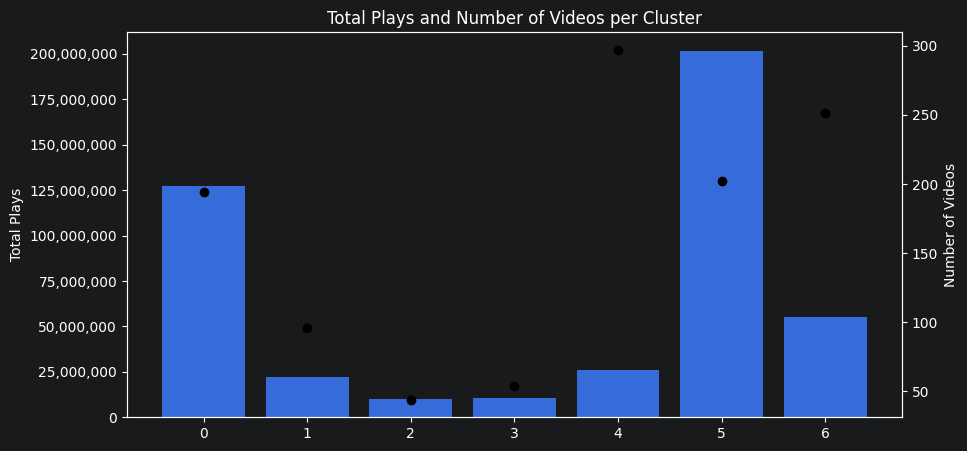

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df2 = averagedf[averagedf["cluster"] != -1]

stats = df2.groupby("cluster").agg({
    "plays": "sum",
    "cluster": "count"
}).rename(columns={"cluster": "num_videos"})

stats = stats.sort_values("plays", ascending=False)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(stats.index, stats["plays"])
ax1.ticklabel_format(style='plain', axis='y')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.set_ylabel("Total Plays")

ax2 = ax1.twinx()
ax2.scatter(stats.index, stats["num_videos"], color="black")  # 👈 dots instead of line
ax2.set_ylabel("Number of Videos")

plt.title("Total Plays and Number of Videos per Cluster")
plt.show()

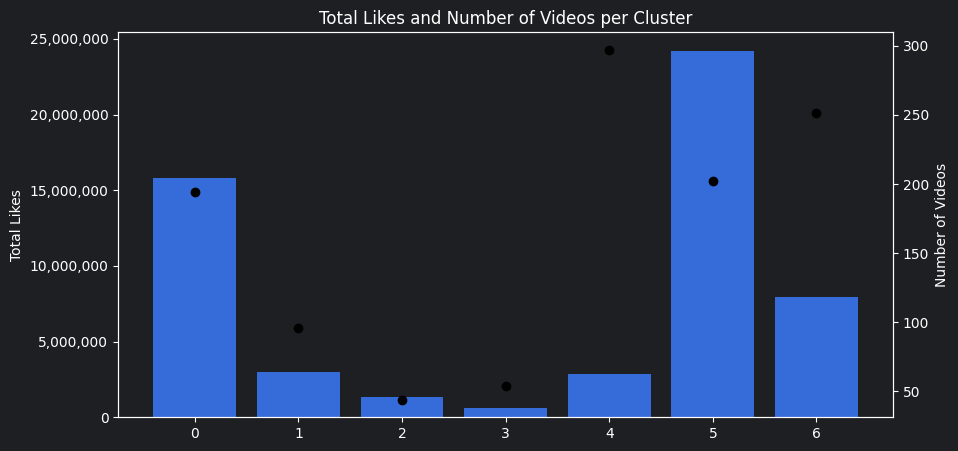

In [106]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df2 = averagedf[averagedf["cluster"] != -1]

stats = df2.groupby("cluster").agg({
    "likes": "sum",
    "cluster": "count"
}).rename(columns={"cluster": "num_videos"})

stats = stats.sort_values("likes", ascending=False)

fig, ax1 = plt.subplots(figsize=(10,5))

ax1.bar(stats.index, stats["likes"])
ax1.ticklabel_format(style='plain', axis='y')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax1.set_ylabel("Total Likes")

ax2 = ax1.twinx()
ax2.scatter(stats.index, stats["num_videos"], color="black")  # 👈 dots instead of line
ax2.set_ylabel("Number of Videos")

plt.title("Total Likes and Number of Videos per Cluster")
plt.show()

In [1]:
cluster_name = {
    0: "Nostaglic feelings and artifacts",
    1: "Physical media enthusiasm",
    2: "Analog photgraphy",
    3: "Opinions and recs on digital detox",
    4: "Analog experiences in vlog format",
    5: "Being offline as the superior",
    6: "Aesthetic showcase of hobbyist activities"
}

AttributeError: This method only works with the ScalarFormatter

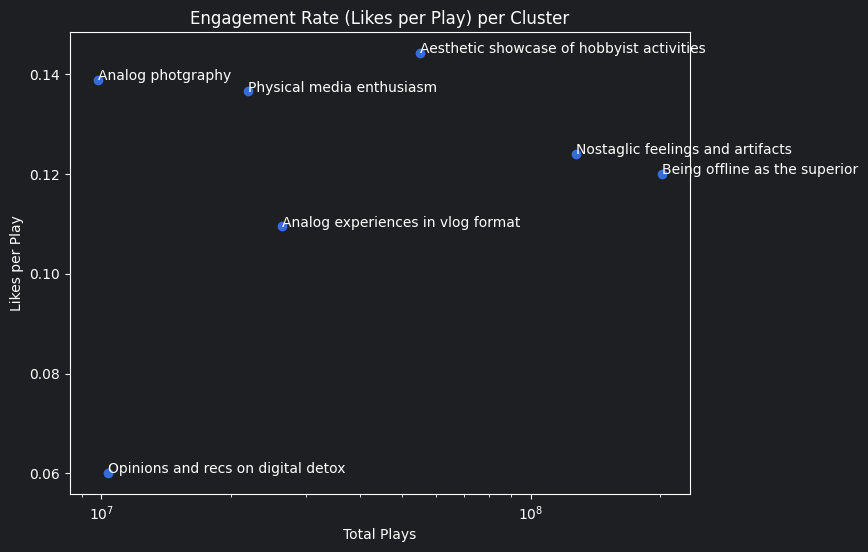

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.ticker as mtick
df2 = averagedf[averagedf["cluster"] != -1]

stats = df2.groupby("cluster").agg({
    "likes": "sum",
    "plays": "sum"
}).reset_index()

# Avoid division by zero
stats = stats[stats["plays"] > 0]

stats["like_rate"] = stats["likes"] / stats["plays"]

plt.figure(figsize=(8,6))
plt.xscale("log")

plt.scatter(stats["plays"], stats["like_rate"])

# label clusters
for _, row in stats.iterrows():
    plt.text(row["plays"], row["like_rate"], cluster_name[row["cluster"]])

plt.xlabel("Total Plays")
plt.ylabel("Likes per Play")
plt.title("Engagement Rate (Likes per Play) per Cluster")

plt.ticklabel_format(style='plain', axis='x')

plt.show()

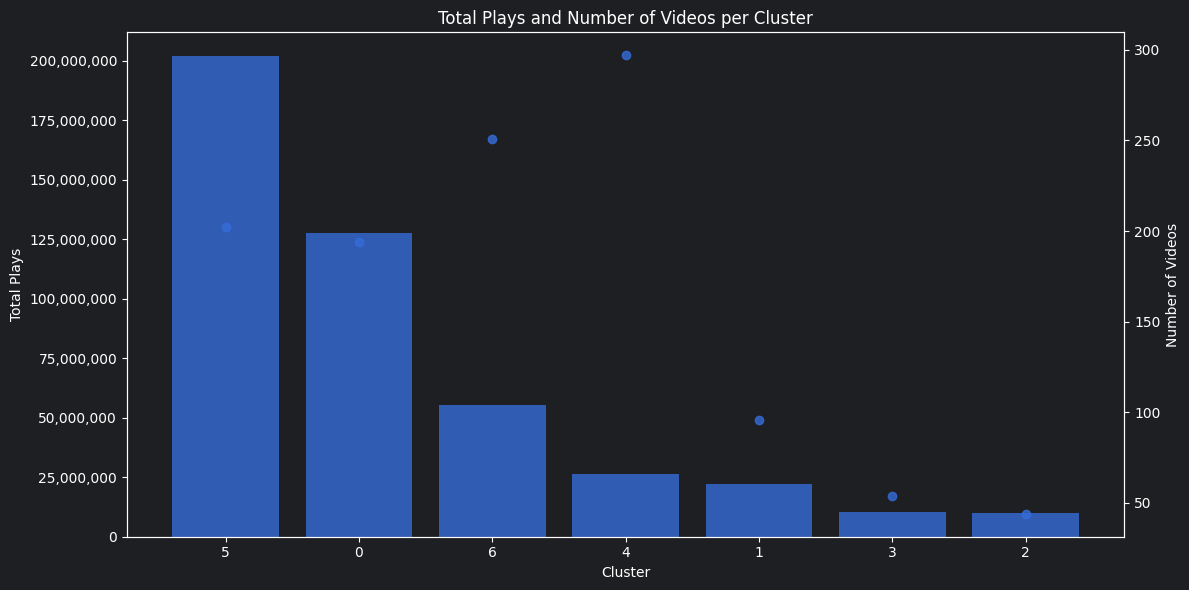

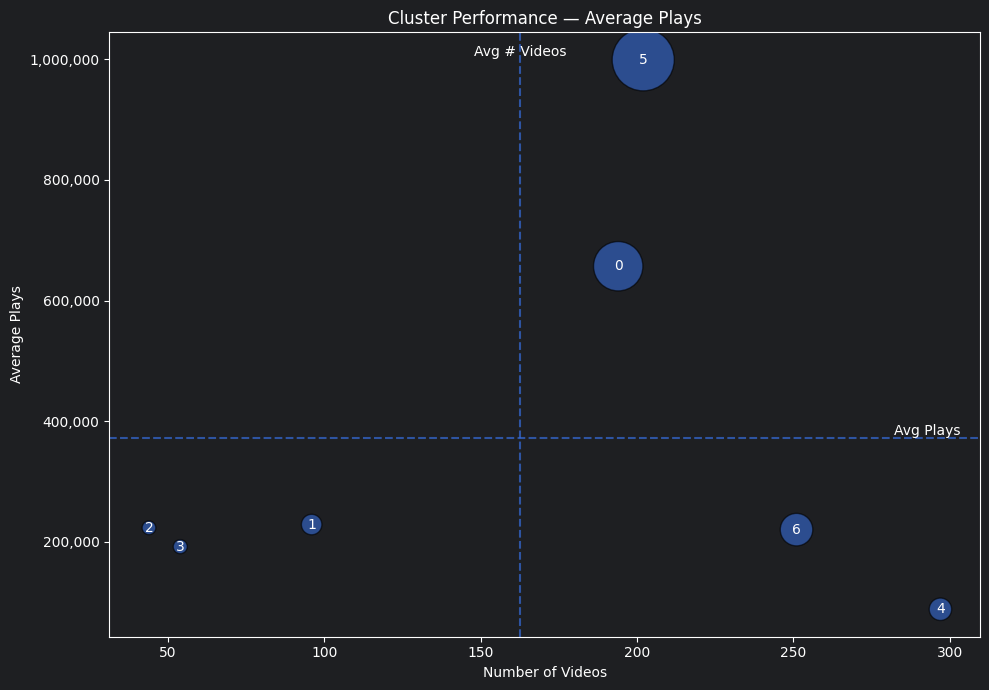

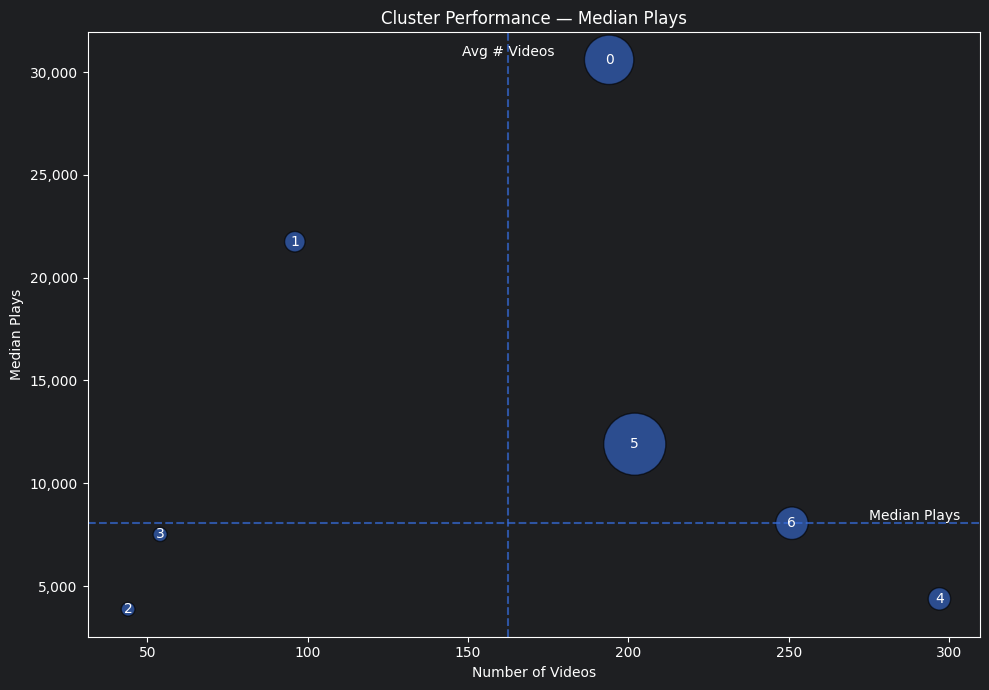

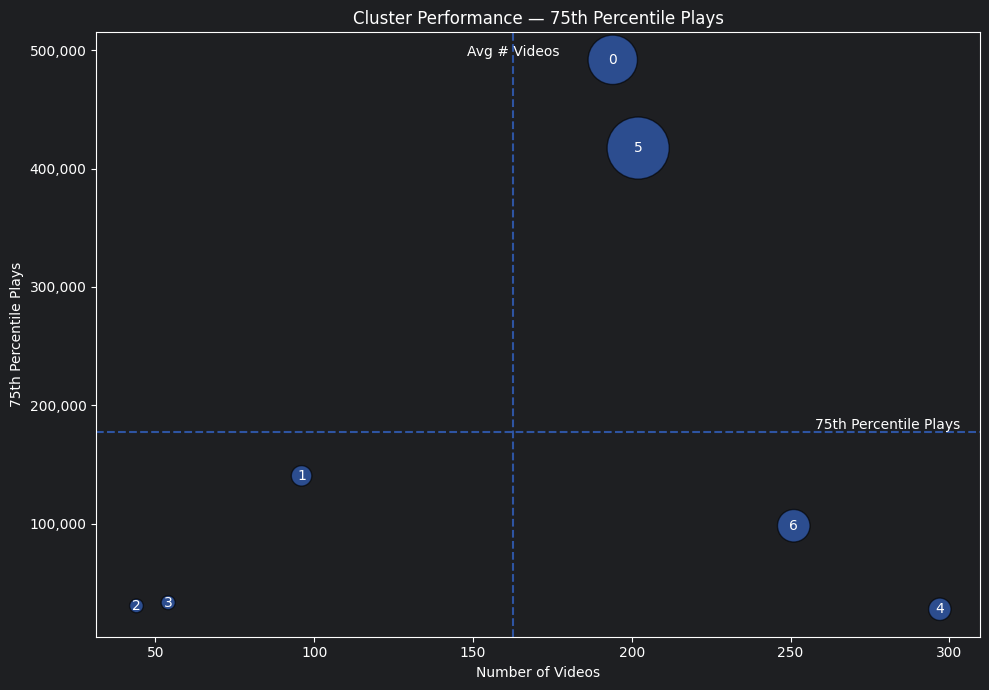

         total_plays      avg_plays  median_plays  p75_plays  num_videos
cluster                                                                 
5          201775548  998888.851485       11900.0   417450.0         202
0          127432411  656868.097938       30600.0   492075.0         194
6           55328114  220430.733068        8055.0    98100.0         251
4           26289567   88517.060606        4373.0    27500.0         297
1           21970170  228855.937500       21750.0   140275.0          96
3           10379874  192219.888889        7506.0    33125.0          54
2            9834095  223502.159091        3869.0    30375.0          44


In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --------------------------------------------------
# 1) PREP DATA
# --------------------------------------------------
# Assumes your dataframe is called df
# and has columns: "cluster" and "plays"

df2 = averagedf[averagedf["cluster"] != -1].copy()

stats = (
    df2.groupby("cluster")["plays"]
    .agg(
        total_plays="sum",
        avg_plays="mean",
        median_plays="median",
        p75_plays=lambda x: x.quantile(0.75),
        num_videos="count",
    )
    .sort_values("total_plays", ascending=False)
)

# Bubble sizes based on total plays
sizes = (stats["total_plays"] / stats["total_plays"].max()) * 2000

# Formatter to avoid scientific notation
def format_axis(ax, x=False, y=False):
    if x:
        ax.ticklabel_format(style="plain", axis="x")
        ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
    if y:
        ax.ticklabel_format(style="plain", axis="y")
        ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

# --------------------------------------------------
# 2) BAR CHART: TOTAL PLAYS + NUMBER OF VIDEOS
# --------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(stats.index.astype(str), stats["total_plays"], alpha=0.8)
ax1.set_title("Total Plays and Number of Videos per Cluster")
ax1.set_xlabel("Cluster")
ax1.set_ylabel("Total Plays")
format_axis(ax1, y=True)

ax2 = ax1.twinx()
ax2.scatter(stats.index.astype(str), stats["num_videos"], alpha=0.8)
ax2.set_ylabel("Number of Videos")
format_axis(ax2, y=True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3) SCATTER: AVERAGE PLAYS
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    stats["num_videos"],
    stats["avg_plays"],
    s=sizes,
    alpha=0.6,
    edgecolors="black",
)

mean_x = stats["num_videos"].mean()
mean_y = stats["avg_plays"].mean()

ax.axvline(mean_x, linestyle="--", alpha=0.7)
ax.axhline(mean_y, linestyle="--", alpha=0.7)

ax.text(mean_x, ax.get_ylim()[1] * 0.98, "Avg # Videos", ha="center", va="top")
ax.text(ax.get_xlim()[1] * 0.98, mean_y, "Avg Plays", ha="right", va="bottom")

for cluster in stats.index:
    ax.text(
        stats.loc[cluster, "num_videos"],
        stats.loc[cluster, "avg_plays"],
        str(cluster),
        ha="center",
        va="center",
    )

ax.set_title("Cluster Performance — Average Plays")
ax.set_xlabel("Number of Videos")
ax.set_ylabel("Average Plays")
format_axis(ax, x=True, y=True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4) SCATTER: MEDIAN PLAYS
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    stats["num_videos"],
    stats["median_plays"],
    s=sizes,
    alpha=0.6,
    edgecolors="black",
)

mean_x = stats["num_videos"].mean()
median_y_overall = stats["median_plays"].median()

ax.axvline(mean_x, linestyle="--", alpha=0.7)
ax.axhline(median_y_overall, linestyle="--", alpha=0.7)

ax.text(mean_x, ax.get_ylim()[1] * 0.98, "Avg # Videos", ha="center", va="top")
ax.text(ax.get_xlim()[1] * 0.98, median_y_overall, "Median Plays", ha="right", va="bottom")

for cluster in stats.index:
    ax.text(
        stats.loc[cluster, "num_videos"],
        stats.loc[cluster, "median_plays"],
        str(cluster),
        ha="center",
        va="center",
    )

ax.set_title("Cluster Performance — Median Plays")
ax.set_xlabel("Number of Videos")
ax.set_ylabel("Median Plays")
format_axis(ax, x=True, y=True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 5) SCATTER: 75TH PERCENTILE PLAYS
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    stats["num_videos"],
    stats["p75_plays"],
    s=sizes,
    alpha=0.6,
    edgecolors="black",
)

mean_x = stats["num_videos"].mean()
p75_overall = stats["p75_plays"].mean()

ax.axvline(mean_x, linestyle="--", alpha=0.7)
ax.axhline(p75_overall, linestyle="--", alpha=0.7)

ax.text(mean_x, ax.get_ylim()[1] * 0.98, "Avg # Videos", ha="center", va="top")
ax.text(ax.get_xlim()[1] * 0.98, p75_overall, "75th Percentile Plays", ha="right", va="bottom")

for cluster in stats.index:
    ax.text(
        stats.loc[cluster, "num_videos"],
        stats.loc[cluster, "p75_plays"],
        str(cluster),
        ha="center",
        va="center",
    )

ax.set_title("Cluster Performance — 75th Percentile Plays")
ax.set_xlabel("Number of Videos")
ax.set_ylabel("75th Percentile Plays")
format_axis(ax, x=True, y=True)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6) OPTIONAL: SEE THE STATS TABLE
# --------------------------------------------------
print(stats)

In [51]:
averagedf.columns

Index(['id', 'thread_id', 'author', 'body', 'timestamp', 'unix_timestamp',
       'collected_from_url', 'author_full', 'author_followers', 'author_likes',
       'author_videos', 'author_avatar', 'stickers', 'is_duet', 'is_ad',
       'is_paid_partnership', 'is_sensitive', 'is_photosensitive',
       'music_name', 'music_id', 'music_url', 'music_thumbnail',
       'music_author', 'video_url', 'tiktok_url', 'thumbnail_url', 'likes',
       'comments', 'shares', 'plays', 'hashtags', 'challenges', 'effects',
       'video_path', 'text_embedding', 'audio_embedding', 'video_embedding',
       'fused_embedding', 'cluster', 'cluster_prob', 'umap_x', 'umap_y'],
      dtype='str')

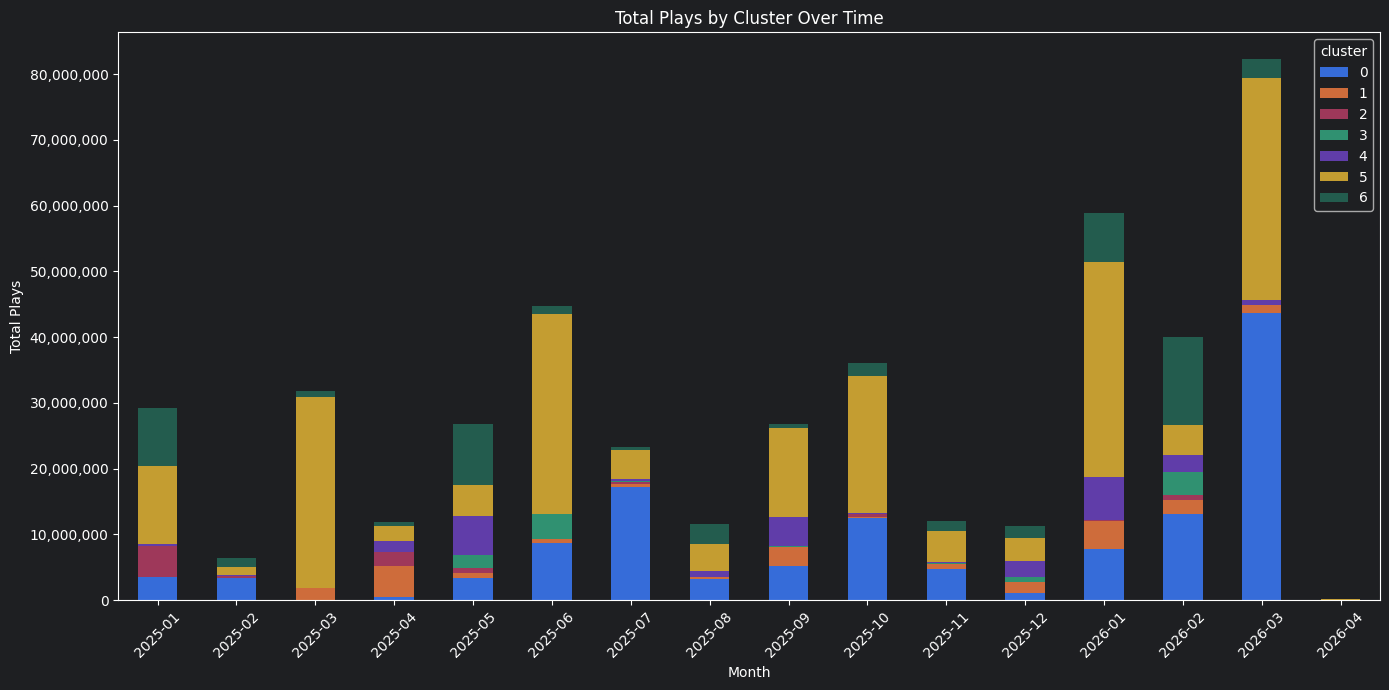

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Copy and prep
df2 = averagedf.copy()
df2 = df2[df2["cluster"] != -1].copy()

# Convert timestamp
df2["timestamp"] = pd.to_datetime(df2["timestamp"], errors="coerce")

# Create month column
df2["month"] = df2["timestamp"].dt.to_period("M").astype(str)

# Aggregate plays by month and cluster
plays_by_cluster = (
    df2.groupby(["month", "cluster"])["plays"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot
ax = plays_by_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

ax.set_title("Total Plays by Cluster Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Total Plays")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

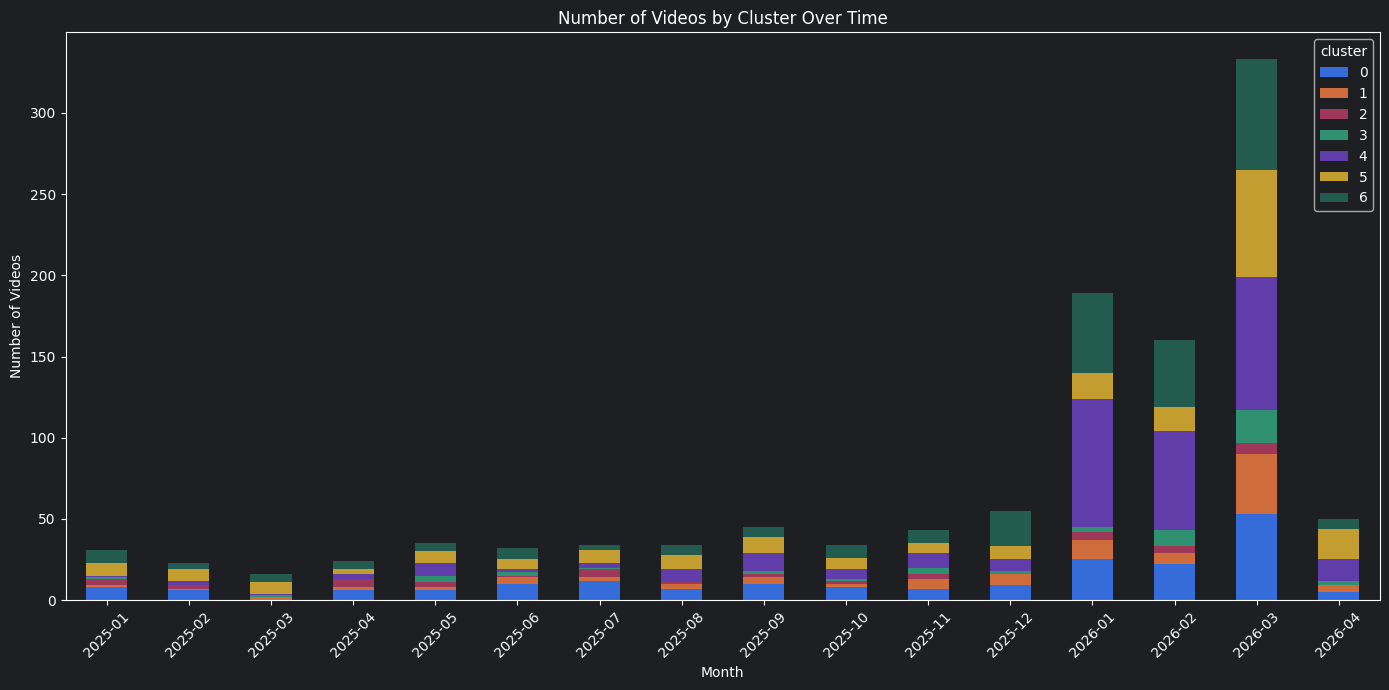

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df2 = averagedf.copy()
df2 = df2[df2["cluster"] != -1].copy()

df2["timestamp"] = pd.to_datetime(df2["timestamp"], errors="coerce")
df2["month"] = df2["timestamp"].dt.to_period("M").astype(str)

videos_by_cluster = (
    df2.groupby(["month", "cluster"])["id"]
    .count()
    .unstack(fill_value=0)
    .sort_index()
)

ax = videos_by_cluster.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

ax.set_title("Number of Videos by Cluster Over Time")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Videos")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

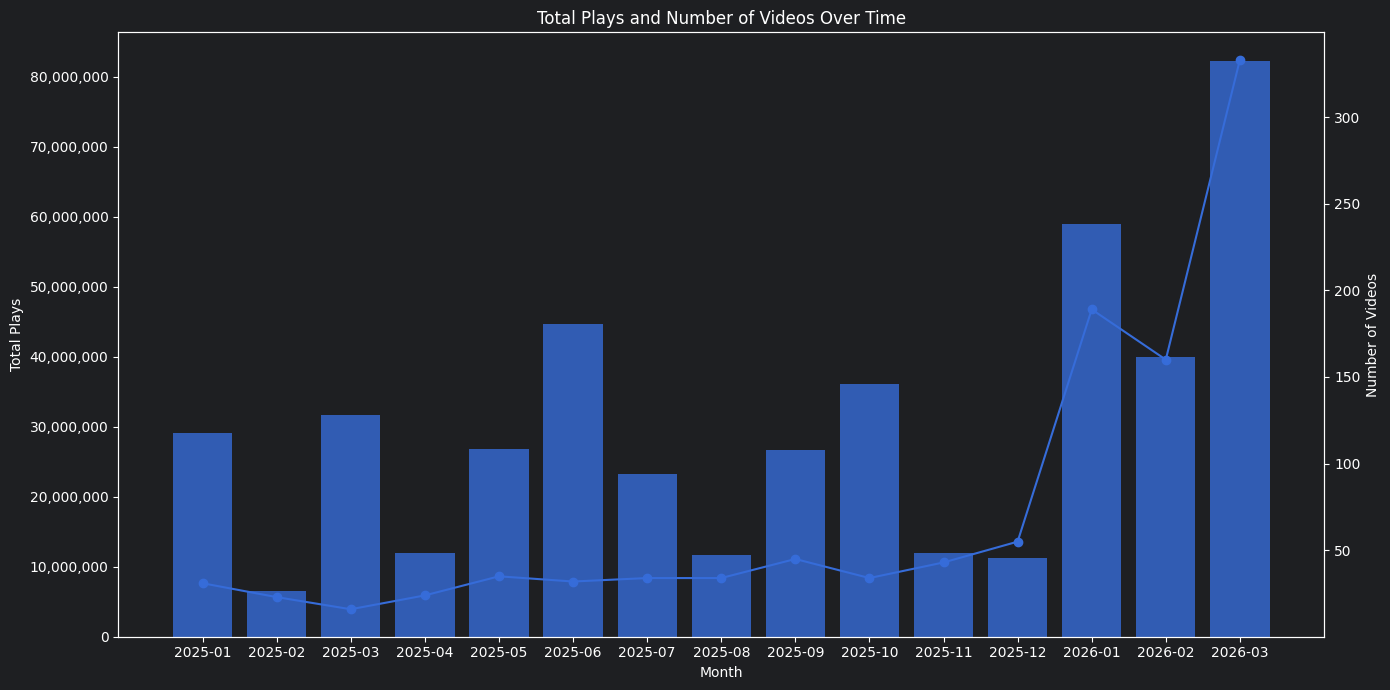

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df2 = averagedf.copy()
df2 = df2[df2["cluster"] != -1].copy()

df2["timestamp"] = pd.to_datetime(df2["timestamp"], errors="coerce")
df2 = df2[df2["timestamp"].dt.to_period("M") != "2026-04"]
df2["month"] = df2["timestamp"].dt.to_period("M").astype(str)

monthly_stats = (
    df2.groupby("month")
    .agg(
        total_plays=("plays", "sum"),
        num_videos=("id", "count")
    )
    .sort_index()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Bars = total plays
ax1.bar(monthly_stats.index, monthly_stats["total_plays"], alpha=0.8)
ax1.set_ylabel("Total Plays")
ax1.set_xlabel("Month")
ax1.set_title("Total Plays and Number of Videos Over Time")
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

# Line = number of videos
ax2 = ax1.twinx()
ax2.plot(monthly_stats.index, monthly_stats["num_videos"], marker="o")
ax2.set_ylabel("Number of Videos")
ax2.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
import pandas as pd

df2 = averagedf[averagedf["cluster"] != -1].copy()
df2["timestamp"] = pd.to_datetime(df2["timestamp"], errors="coerce")
df2["month"] = df2["timestamp"].dt.to_period("M")

# remove April 2026
df2 = df2[df2["month"] != "2026-04"]

# plays per cluster per month
monthly = (
    df2.groupby(["month", "cluster"])["plays"]
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

# growth = last month - first month
growth = monthly.iloc[-1] - monthly.iloc[0]

growth.sort_values(ascending=False)

growth_rate = (monthly.iloc[-1] - monthly.iloc[0]) / (monthly.iloc[0] + 1)

growth_rate.sort_values(ascending=False)

import numpy as np

slopes = {}

for cluster in monthly.columns:
    y = monthly[cluster].values
    x = np.arange(len(y))

    slope = np.polyfit(x, y, 1)[0]  # linear trend
    slopes[cluster] = slope

slopes = pd.Series(slopes).sort_values(ascending=False)

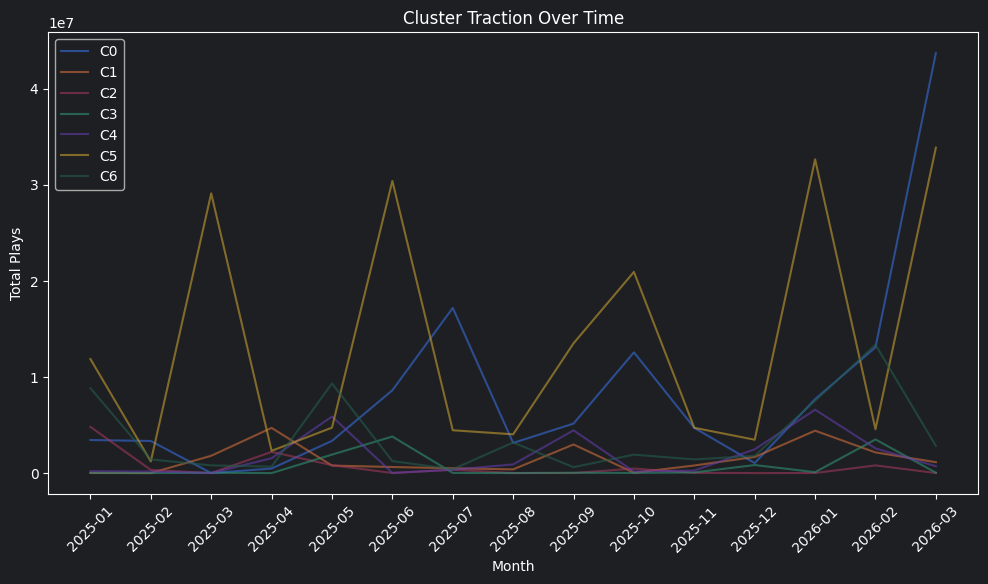

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for cluster in monthly.columns:
    plt.plot(monthly.index.astype(str), monthly[cluster], label=f"C{cluster}", alpha=0.6)

plt.legend()
plt.title("Cluster Traction Over Time")
plt.xlabel("Month")
plt.ylabel("Total Plays")

plt.xticks(rotation=45)
plt.show()

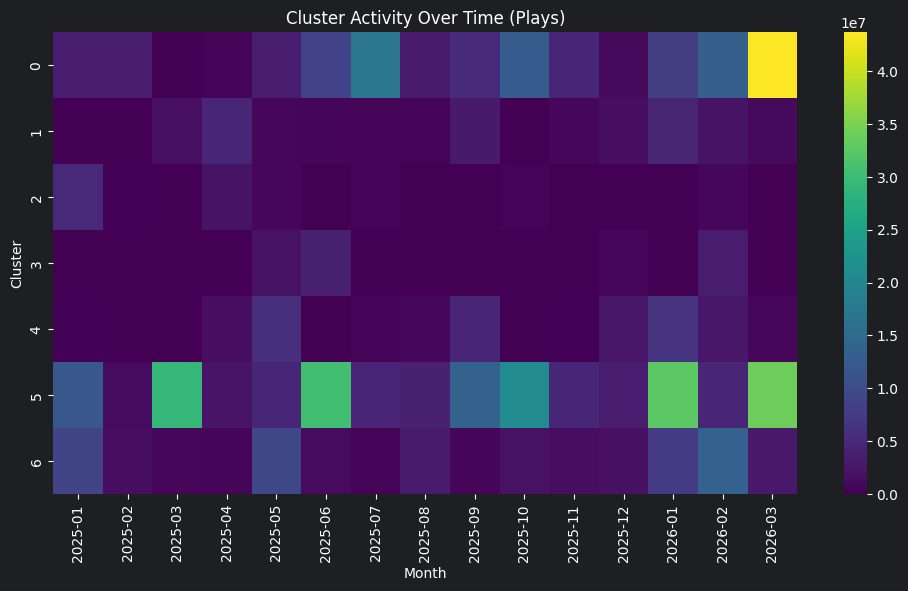

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12,6))

sns.heatmap(
    monthly.T,   # clusters on Y axis
    cmap="viridis"
)

# ax.ticklabel_format(style='plain', axis='both')

plt.title("Cluster Activity Over Time (Plays)")
plt.xlabel("Month")
plt.ylabel("Cluster")

plt.show()

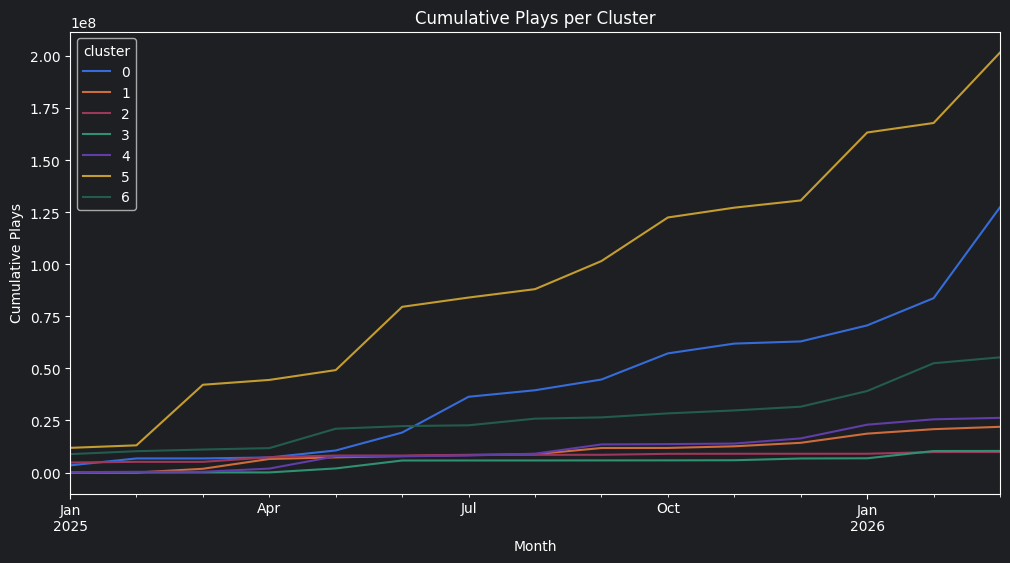

In [68]:
cumulative = monthly.cumsum()

cumulative.plot(figsize=(12,6))

plt.title("Cumulative Plays per Cluster")
plt.xlabel("Month")
plt.ylabel("Cumulative Plays")

plt.show()

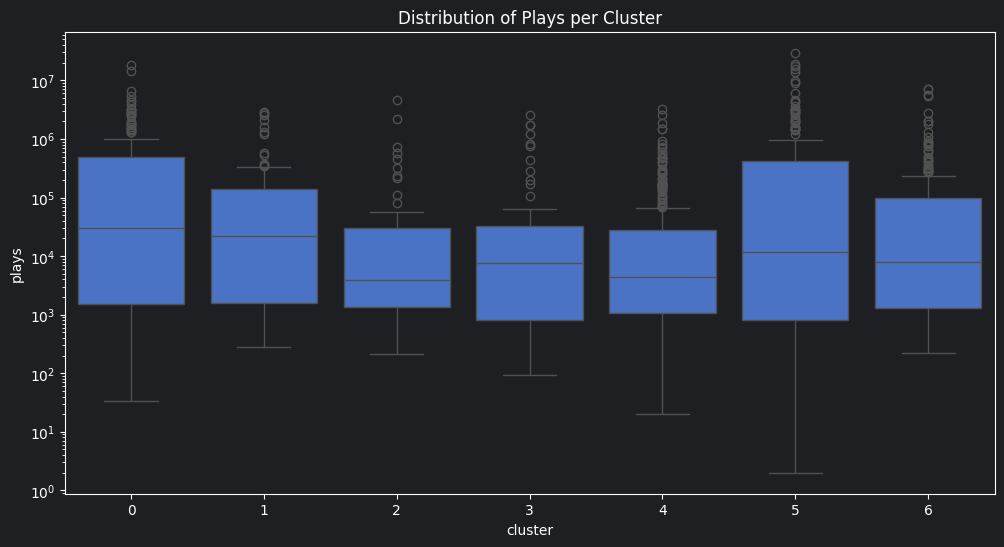

In [72]:
import seaborn as sns

plt.figure(figsize=(12,6))

sns.boxplot(data=averagedf[averagedf["cluster"] != -1], x="cluster", y="plays")

plt.yscale("log")  # important for plays
plt.title("Distribution of Plays per Cluster")

plt.show()

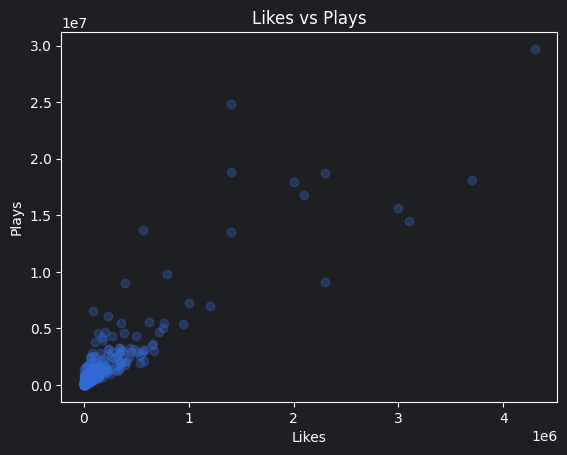

In [75]:
plt.scatter(averagedf["likes"], averagedf["plays"], alpha=0.3)

plt.xlabel("Likes")
plt.ylabel("Plays")
plt.title("Likes vs Plays")

plt.show()

In [80]:
high_play_df = averagedf[averagedf["plays"] >= 1_000_000].copy()
high_play_df = high_play_df.sort_values("plays", ascending=False)

high_play_df[[
    "id", "cluster", "plays", "likes", "comments", "shares",
    "author", "body", "timestamp", "tiktok_url"
]].head(10)

,id,cluster,plays,likes,comments,shares,author,body,timestamp,tiktok_url
171,7520450650543557910,5,29700000,4300000,18400,475700,b2b2213152d13213006c5deb63f7271d768afd9952ed8bbb,Proof we are getting old #nostalgia #fyp,2025-06-27 02:30:03,https://www.tiktok.com/@nostalgia.moments.36/v...
183,7597253593040751927,-1,24800000,1400000,15900,204400,f4a1c0d373d790478de31930f945ad32967e7901de3b5951,"If You Were Born in 1986, This One’s for You #...",2026-01-20 01:44:30,https://www.tiktok.com/@80s90sthrowback/video/...
184,7460598588591197486,-1,18800000,1400000,4797,27900,4c671f3079b15cfafb4bdf3389a527366ccedd6bcd990abf,Claire’s was that girl #nostalgia #2000s #2003...,2025-01-16 19:32:59,https://www.tiktok.com/@isabelclanc/video/7460...
179,7559887489478036758,5,18700000,2300000,5535,230200,134ef5e0a5be57c13ccc64984034c2474ae41784242031c7,Nostalgia will k*ll me a day... 🔥✨️ #5MinuteCr...,2025-10-11 09:04:34,https://www.tiktok.com/@vicky.novikova/video/7...
1438,7617534112039046433,0,18100000,3700000,5564,230200,fd32429e65045bc55af07b0e45e48cf467303eda30b425b9,#trampoline #childhood #nostalgia,2026-03-15 17:22:57,https://www.tiktok.com/@lene.tt/video/76175341...
137,7590254127926594829,5,17900000,2000000,5165,463400,55bee639f032867a86f0222efd4bad4afc396f1ee9fd2b5e,2016 is now officially a decade ago.. 💔 #nosta...,2026-01-01 05:02:50,https://www.tiktok.com/@childhoodcore8/video/7...
192,7462891147187244294,-1,16800000,2100000,6838,69500,1cf9c5ee3941ea3c179c7934b9b61069a9e75ddd064490de,@Joey A The boy who went viral in recent days ...,2025-01-22 23:49:18,https://www.tiktok.com/@nostalgia.70/video/746...
1512,7616577325399870734,5,15600000,3000000,17200,387500,7915cc922367b3d787f5336a7ad7c043f12c03af91fe88c4,6 years ago today…#6yearsago #2020 #covid #qua...,2026-03-13 03:30:34,https://www.tiktok.com/@.serenity_31/video/761...
105,7622465740074962183,0,14500000,3100000,15100,219600,fa72947025389e613c3b89cdeaf84ef0742d2ea83373c788,another one #minecraft #nostalgic #targetaudie...,2026-03-29 00:20:15,https://www.tiktok.com/@shock..edits/video/762...
136,7486631343607074054,5,13700000,566200,12300,41700,1cf9c5ee3941ea3c179c7934b9b61069a9e75ddd064490de,Nostalgia 1991 🪩🕺💃 #nostalgia #discoteca #flas...,2025-03-27 23:13:22,https://www.tiktok.com/@nostalgia.70/video/748...


In [83]:
top_10_highest = high_play_df.head(10)

In [84]:
top_10_highest.to_csv("top_10_highest.csv")

In [81]:
df2 = averagedf.copy()
df2["like_to_play_ratio"] = df2["likes"] / df2["plays"].replace(0, pd.NA)

weird_high_play = (
    df2[df2["plays"] >= df2["plays"].quantile(0.95)]
    .sort_values("like_to_play_ratio", ascending=True)
)

weird_high_play[[
    "plays", "likes", "like_to_play_ratio", "cluster",
    "author", "body", "timestamp", "tiktok_url"
]].head(20)

,plays,likes,like_to_play_ratio,cluster,author,body,timestamp,tiktok_url
955,6500000,92000,0.014154,0,b7f3258cafb929e8453d9b10f33e4c1a3fc1ba1fff0894c3,🎠 #zweefmolenwiekstra #kermis #reiziger #zweve...,2026-02-22 21:01:19,https://www.tiktok.com/@zweefmolenwiekstra/vid...
1136,2500000,59100,0.023640,-1,f3547ee8212ee8e0696bfdca25dc417eafc7bf27dc36846b,A Finnish teacher invented a method that remov...,2026-01-08 22:50:38,https://www.tiktok.com/@adelxunlocked/video/75...
1142,2500000,66000,0.026400,-1,fb0453ca54f95558c3a025a821366f92a1821f37c1c8754d,"Refrescante, saludable y delicioso! 🥒🍍🍋 Prepar...",2025-02-26 18:29:03,https://www.tiktok.com/@mecatoskatita/video/74...
445,2800000,79000,0.028214,0,f4a75678ca4dd300b2b35c800ffc632e8c07c8572435f332,#health #liver #detox #healthtips #doctor,2025-09-29 15:04:18,https://www.tiktok.com/@dr.williams.md/video/7...
770,3800000,109400,0.028789,0,28b7b5ef9d3d47f1fbbe6f26e602b8088be0802d552f6e3f,#vidanaroça#nostalgia #interior #fyp #viral,2025-10-13 20:05:12,https://www.tiktok.com/@nostalgiabrasileira0/v...
1470,4600000,134000,0.029130,5,df45aa4bfc63b643ec9e9b6ae52914b6abd8d697c1ffab29,2020 nostalgia heats hard... | idea by:me | #n...,2025-09-26 01:51:18,https://www.tiktok.com/@.jistroxlr7/video/7554...
391,2000000,59100,0.029550,-1,07b3fc4c71c4a3c31235fe067debbed3b6f8ad7ae5c8192d,Reset Challenge — Day 1: Detox ✨ 🥕 Carrots ar...,2026-02-17 20:33:58,https://www.tiktok.com/@recipes.by.ani/video/7...
1129,1900000,56500,0.029737,4,0a13d96b61bbc66515848f113b0b95a848e09b1836c3b54a,Poznajcie Polski antysmartfon Mudita Kompakt. ...,2025-05-19 09:07:56,https://www.tiktok.com/@dailywebpl/video/75060...
417,2600000,88800,0.034154,3,444db9f4be600cf09f3d210c34d682ba790eb19cc7a805af,Kenapa sih orang yang udah kalah main jud0l te...,2025-06-04 07:56:10,https://www.tiktok.com/@millenialzkece/video/7...
150,6100000,227200,0.037246,5,1cf9c5ee3941ea3c179c7934b9b61069a9e75ddd064490de,Nostalgia 1989 🪩🕺💃 #discoteca #danceteria #nos...,2025-03-06 19:02:12,https://www.tiktok.com/@nostalgia.70/video/747...


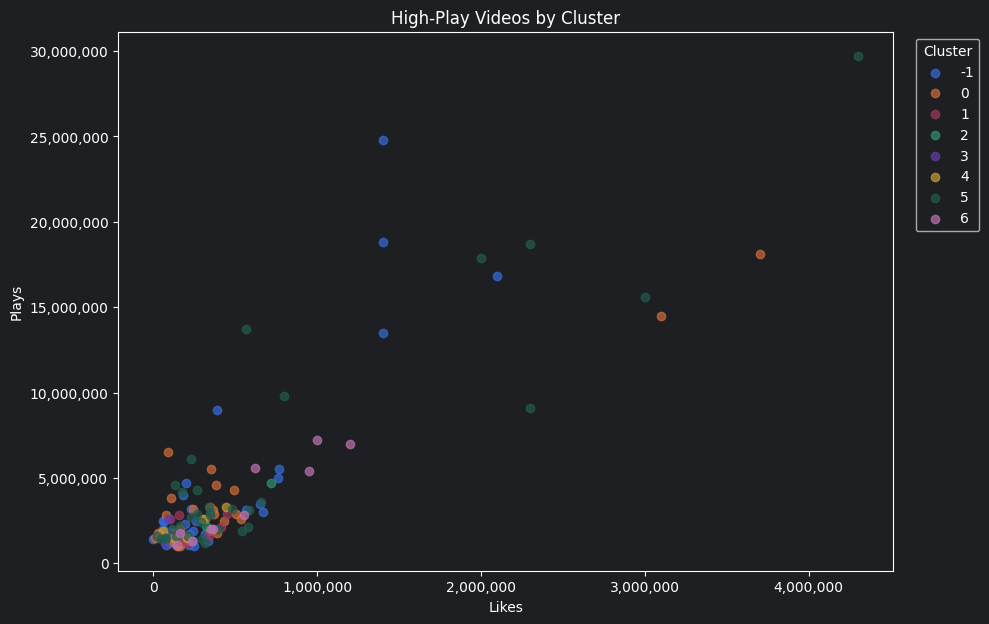

In [82]:
plt.figure(figsize=(10, 7))

for cluster, g in high_play_df.groupby("cluster"):
    plt.scatter(g["likes"], g["plays"], alpha=0.7, label=str(cluster))

ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

plt.xlabel("Likes")
plt.ylabel("Plays")
plt.title("High-Play Videos by Cluster")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.show()

In [1]:
import pandas as pd

In [4]:
top10noise = pd.read_feather("ten_percent_noise_cluster.feather")

In [5]:
top10noise

,id,thread_id,author,body,timestamp,unix_timestamp,collected_from_url,author_full,author_followers,author_likes,...,effects,video_path,text_embedding,audio_embedding,video_embedding,fused_embedding,cluster,cluster_prob,umap_x,umap_y
183,7597253593040751927,7597253593040751927,f4a1c0d373d790478de31930f945ad32967e7901de3b5951,"If You Were Born in 1986, This One’s for You #...",2026-01-20 01:44:30,1768869870,https://www.tiktok.com/tag/nostalgia,fdf598f91c9a54016360ffbe5e66052f39505f77e00e5439,f25b1a9f2ced2a166a905e6721393b182194825371d69d78,1c7b318bfc71bfa276c3f036b8ea5aff24e0adb32058b19e,...,NaN,extracted_from_zips/7597253593040751927.mp4,"[4.003008, 3.4071298, -1.6076349, -0.58673376,...","[0.17009963, 0.18991192, -0.66830045, 0.367250...","[0.00088454044, 0.01638999, -0.011222858, -0.0...","[0.025937011, 0.03251538, -0.036278706, -0.008...",-1,0.0,1.717765,4.335151
184,7460598588591197486,7460598588591197486,4c671f3079b15cfafb4bdf3389a527366ccedd6bcd990abf,Claire’s was that girl #nostalgia #2000s #2003...,2025-01-16 19:32:59,1737052379,https://www.tiktok.com/tag/nostalgia,f5877b0316ebe474c9d4e3a34f26cf7a919a8e6073be8d1c,9595475efbf0c639d879a1322473683d6c54c26bc9ef8b89,016e0b6871d822213488ea28397cb736617179e7cd1868ec,...,NaN,extracted_from_zips/7460598588591197486.mp4,"[-1.1213442, -4.3568316, 1.8114429, 3.8248055,...","[0.12879461, -0.15810885, -0.035432186, -0.499...","[0.0052896366, 0.0048578405, 0.017490244, -0.0...","[0.0014852869, -0.023451652, 0.015951594, -0.0...",-1,0.0,0.217923,4.050557
192,7462891147187244294,7462891147187244294,1cf9c5ee3941ea3c179c7934b9b61069a9e75ddd064490de,@Joey A The boy who went viral in recent days ...,2025-01-22 23:49:18,1737586158,https://www.tiktok.com/tag/nostalgia,54bc31c0d3b17f4a5c35fbf7a128e6a1249c797077889b82,9a36f6ae77bece55fae154e892b6933b720840546d41618b,19cd5a676ba8aaadf1feb74bdd9b4824dc75d6c9c889f1c7,...,2016,extracted_from_zips/7462891147187244294.mp4,"[4.0314083, 6.4092755, -0.3841084, -4.3518653,...","[-0.083399236, 0.06918978, -0.038736064, 0.228...","[-0.0002550163, 0.002662559, 0.023382, -0.0195...","[0.016314274, 0.03505655, 0.01025999, -0.02403...",-1,0.0,0.848357,4.621428
173,7519522253118180631,7519522253118180631,3614e3f3084ee5edf09dd194ce78991ec7aaa3006ebbb8d5,Nostalgia #fyppppppppppppppppppppppp #fypppppp...,2025-06-24 14:26:51,1750768011,https://www.tiktok.com/tag/nostalgia,bd7408a708b36fe255be5f0353da9655e5374fe22f7e9580,1df92a1a12a0b7f0069d26d5bd37483913c4c0c974521555,96983918b638141c237a57ad5c6ceaf22554b81c401807a7,...,NaN,extracted_from_zips/7519522253118180631.mp4,"[1.6213156, -1.6751921, 2.1603665, 0.022401284...","[-0.06616197, -0.14996585, 0.077542424, -0.294...","[0.025434695, 0.03751248, 0.019860892, -0.0256...","[0.022192245, 0.0084371, 0.02627301, -0.024198...",-1,0.0,1.475067,5.411588
768,7471393598462905605,7471393598462905605,b7bf1f0f51c5a91a5e085b11b0cecae85b6fac7ad4ad0f5e,Discoteca 1993 🪩🕺💃 #discoteca #nostalgia #nost...,2025-02-14 21:43:09,1739565789,https://www.tiktok.com/tag/nostalgia,54bc31c0d3b17f4a5c35fbf7a128e6a1249c797077889b82,f7ef4a5b77387bbded7459c88fc254887fc9562ced00ae09,2d42481fbc5325f6f5c7826ae44b920e8871e0ce3597c9a9,...,2016,extracted_from_zips/7471393598462905605.mp4,"[1.9354734, 4.023885, -1.5611929, 0.85343534, ...","[0.079712845, -0.13556333, -0.51529425, -0.206...","[0.011160441, 0.019848451, 0.0004153444, -0.03...","[0.017329946, 0.025920974, -0.021544205, -0.02...",-1,0.0,0.444856,4.647528
175,7545651770416975126,7545651770416975126,adc67046664311ff22d746a7c6caed8f17facf8410cb6ee8,🥲🥲 #enfance #2000s #nostalgia #fyp #moment,2025-09-03 00:22:51,1756851771,https://www.tiktok.com/tag/nostalgia,140a7ee2accd48437f2b7eacb945984122b765b6751a0021,4586fca395a3ff5a30606b8c8443c3f328b1d52afcbd2de3,006aa50be1d3a8dbd494c33c40ed1428257d378cfd9d8315,...,NaN,extracted_from_zips/7545651770416975126.mp4,"[2.8258753, -0.512017, -3.5753887, -1.3477991,...","[-0.32188547, -0.3319272, 0.021594236, -0.2294...","[0.0149709955, 0.0195166, 0.02526384, -0

In [7]:
annotated_noise = pd.DataFrame(top10noise['id'])

In [9]:
annotated_noise["theme"] = -1

In [10]:
annotated_noise

,id,theme
183,7597253593040751927,-1
184,7460598588591197486,-1
192,7462891147187244294,-1
173,7519522253118180631,-1
768,7471393598462905605,-1
175,7545651770416975126,-1
921,7496552706736229654,-1
451,7521838892991991095,-1
1141,7568225273997462814,-1
782,7572745771020242183,-1


In [ ]:
niostalgia
vibey aesthetic with/wo text with no meaning
vibwy aesthetic with meaning
anything with real meaning (person talking)

In [22]:
annotated_noise.loc[annotated_noise['id'] == 7607149972340919574]

,id,theme
121,7607149972340919574,-1


In [48]:
annotated_noise.at[926, "theme"] = 2

In [49]:
annotated_noise.groupby(["theme"]).count()

,id
theme,
-1,18
1,10
2,6
3,3
4,4


In [53]:
averagedf.shape

(1549, 42)

In [54]:
1549*0.05

77.45

In [56]:
top5percent = (
    averagedf
    .sort_values("plays", ascending=False)
    .head(77)
)

In [57]:
top5percent

,id,thread_id,author,body,timestamp,unix_timestamp,collected_from_url,author_full,author_followers,author_likes,...,effects,video_path,text_embedding,audio_embedding,video_embedding,fused_embedding,cluster,cluster_prob,umap_x,umap_y
171,7520450650543557910,7520450650543557910,b2b2213152d13213006c5deb63f7271d768afd9952ed8bbb,Proof we are getting old #nostalgia #fyp,2025-06-27 02:30:03,1750984203,https://www.tiktok.com/tag/nostalgia,b2b2213152d13213006c5deb63f7271d768afd9952ed8bbb,1b43da9ae8fd9ff8015ed7982555599c4794a18494125798,54a66220f37bf14659a89682216cbdfac9bfa566290e09cd,...,NaN,extracted_from_zips/7520450650543557910.mp4,"[5.3362756, -1.6075488, 3.159558, -2.9861538, ...","[-0.10382801, 0.19656818, -0.116578676, 0.6476...","[0.035843324, 0.008914192, 0.010794985, -0.031...","[0.044879515, 0.003153468, 0.018727478, -0.014...",5,1.0,1.691897,4.231071
183,7597253593040751927,7597253593040751927,f4a1c0d373d790478de31930f945ad32967e7901de3b5951,"If You Were Born in 1986, This One’s for You #...",2026-01-20 01:44:30,1768869870,https://www.tiktok.com/tag/nostalgia,fdf598f91c9a54016360ffbe5e66052f39505f77e00e5439,f25b1a9f2ced2a166a905e6721393b182194825371d69d78,1c7b318bfc71bfa276c3f036b8ea5aff24e0adb32058b19e,...,NaN,extracted_from_zips/7597253593040751927.mp4,"[4.003008, 3.4071298, -1.6076349, -0.58673376,...","[0.17009963, 0.18991192, -0.66830045, 0.367250...","[0.00088454044, 0.01638999, -0.011222858, -0.0...","[0.025937011, 0.03251538, -0.036278706, -0.008...",-1,0.0,1.717765,4.335151
184,7460598588591197486,7460598588591197486,4c671f3079b15cfafb4bdf3389a527366ccedd6bcd990abf,Claire’s was that girl #nostalgia #2000s #2003...,2025-01-16 19:32:59,1737052379,https://www.tiktok.com/tag/nostalgia,f5877b0316ebe474c9d4e3a34f26cf7a919a8e6073be8d1c,9595475efbf0c639d879a1322473683d6c54c26bc9ef8b89,016e0b6871d822213488ea28397cb736617179e7cd1868ec,...,NaN,extracted_from_zips/7460598588591197486.mp4,"[-1.1213442, -4.3568316, 1.8114429, 3.8248055,...","[0.12879461, -0.15810885, -0.035432186, -0.499...","[0.0052896366, 0.0048578405, 0.017490244, -0.0...","[0.0014852869, -0.023451652, 0.015951594, -0.0...",-1,0.0,0.217923,4.050557
179,7559887489478036758,7559887489478036758,134ef5e0a5be57c13ccc64984034c2474ae41784242031c7,Nostalgia will k*ll me a day... 🔥✨️ #5MinuteCr...,2025-10-11 09:04:34,1760166274,https://www.tiktok.com/tag/nostalgia,a50fd955f49032d76797fd1b48e55b9ea4dcbc478adbd3c3,fcd3b1cfd56460cd32a310c718b2eef0c1d66d5fd485bfd0,eadadd46d692ad2bff6338bc4d0ab7d76c6e0cdcdc67aaeb,...,NaN,videos/7559887489478036758.mp4,"[1.4601829, 0.9496505, 1.3599604, 0.13501327, ...","[-0.06469222, -0.36731866, -0.2526401, -0.1759...","[0.014537585, 0.016422203, 0.009196022, -0.034...","[0.013719316, 0.0030199958, 0.0044219545, -0.0...",5,1.0,1.261787,4.263579
1438,7617534112039046433,7617534112039046433,fd32429e65045bc55af07b0e45e48cf467303eda30b425b9,#trampoline #childhood #nostalgia,2026-03-15 17:22:57,1773591777,https://www.tiktok.com/tag/nostalgia,b1cfaa6150a0c9fa048c25bfa834df9494b9faa4d984b83f,0fe2ebf07263b26e5522542799ee74c7b7bbbbf25b58a180,4fe50bfe8de287a16f53cebea6a3f16221e623ec9544af20,...,"Green Screen,Green Screen",videos/7617534112039046433.mp4,"[0.95751333, 0.0611063, -0.89676195, -2.106427...","[-0.072347276, 0.14235309, 0.09682864, 0.17440...","[0.01674936, 0.0041544824, 0.018339442, -0.014...","[0.013525264, 0.008290562, 0.011564923, -0.013...",0,1.0,2.246954,5.930139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,7620486632176700705,7620486632176700705,13e913bfb546d93f2885596f3f397c77f7e6d5566cdd8847,I don't wanna grow up anymore. #foreveryoung #...,2026-03-23 16:20:14,1774279214,https://www.tiktok.com/tag/nostalgia,067a5770cc94cd8426f5c35665814b79d9fdd39829addfb1,e8ed4693e0d7bb5d0bc33197ad0709903329371f55c8a03f,e7c6ab24703af459bec9ad54a6b15353339e7357692f3c52,...,"Svelamento progressivo,BLUE",videos/7620486632176700705.mp4,"[0.14912643, 0.37219402, 0.2653933, -4.539115,...","[0.06608174, 0.

In [58]:
annotated_clusters = pd.DataFrame(top5percent['id'])

In [59]:
annotated_clusters["theme"] = -1

In [60]:
annotated_clusters

,id,theme
171,7520450650543557910,-1
183,7597253593040751927,-1
184,7460598588591197486,-1
179,7559887489478036758,-1
1438,7617534112039046433,-1
...,...,...
122,7620486632176700705,-1
1453,7605207651630337313,-1
415,7488421705803631894,-1
1439,7564123430736399638,-1


In [99]:
annotated_clusters.at[1453, "theme"] = 1

In [100]:
annotated_clusters.groupby(["theme"]).count()

,id
theme,
-1,38
1,17
2,14
3,5
4,3
